This notebook contains the following analyses:
- Effect of the different epicore modes and parameters on the identified peptide groups. 
- Dataset complexity reduction achieved by epicore. 
- Peptide offset to the consensus sequences. 
- The peptide group allotype compositions for class1 and class2.
- Runtime analysis. 

The following datasets were used in this analysis:
- Immunopeptidome benign reference dataset, comprising data from the [HLA-Ligand atlas](https://jitc.bmj.com/content/9/4/e002071), a [benign reference dataset from Hoenisch Gravel et al.](https://www.nature.com/articles/s41467-023-42692-7) and a [benign reference dataset from Scheid et al.](https://link.springer.com/article/10.1186/s13059-025-03763-8). 
- Immunopeptidome data with known allotypes. The dataset was kindly provided by Jonas Scheid, who collected the data from various sources in context of the immunotype publication. The dataset corresponds to a version before filtering for classI peptides. 

In [1]:
import pandas as pd
from time import time
import ast
import sys
import glob
import matplotlib.pyplot as plt
from matplotlib.axis import Axis
from Bio import SeqIO
import seaborn as sns
import numpy as np
from matplotlib_venn import venn2
import subprocess
sys.path.append('../functions')
from peptide_annotator import get_peptide_lengths, proteome_to_dict, create_fasta_dict, annotate_peptides, add_positions

### Prepare data for epicore

In [ ]:
# load data
benign_df = pd.read_csv('/mnt/volume/jana/thesis/data/newbenign/benign_HLA_Ligand_Atlas_Lumos_timsTOF.tsv',sep='\t')[['peptide_sequence','mhc_class','dignity','donor_code','all_hla_alleles_donor','biological_material_name','qbic_project_code']]
benign_df = benign_df.rename(columns={'peptide_sequence':'sequence','donor_code':'sample','all_hla_alleles_donor':'HLA Typing', 'dignity':'condition'})
benign_df = benign_df.drop_duplicates(['sequence','mhc_class','condition','sample','HLA Typing'])
# combine donor and tissue information for samples
benign_df['sample'] = benign_df['sample']+'_'+benign_df['biological_material_name']
# annotate peptides
lengths = get_peptide_lengths(benign_df)
proteome_dict = proteome_to_dict('/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta')
fasta_dict = create_fasta_dict(proteome_dict, lengths)
benign_df = annotate_peptides(fasta_dict, benign_df)
benign_df = add_positions(proteome_dict, benign_df, 'accessions', 'sequence')
benign_df[benign_df['mhc_class']=='I'].to_csv('reference_class1.csv')
benign_df[benign_df['mhc_class']=='II'].to_csv('reference_class2.csv')

In [ ]:
print(f"The dataset comprises {len(benign_df[benign_df['mhc_class']=='I']['sequence'])} ({len(benign_df[benign_df['mhc_class']=='I']['sequence'].drop_duplicates())} unique) classI peptides.")
print(f"The dataset comprises {len(benign_df[benign_df['mhc_class']=='II']['sequence'])} ({len(benign_df[benign_df['mhc_class']=='II']['sequence'].drop_duplicates())} unique) classII peptides.")

The dataset comprises 801907 (267526 unique) classI peptides.
The dataset comprises 1098916 (397566 unique) classII peptides.


In [ ]:
print(f"The benign reference dataset includes {len(benign_df[benign_df['mhc_class']=='I']['sample'].unique())} classI samples.")
print(f"The benign reference dataset includes {len(benign_df[benign_df['mhc_class']=='II']['sample'].unique())}  classII samples.")

The benign reference dataset includes 283 classI samples.
The benign reference dataset includes 286  classII samples.


In [ ]:
benign_df['HLA Typing'] = benign_df['HLA Typing'].str.split(';')
print(f"The dataset includes the peptides being presented by {len([allotype for allotype in benign_df[benign_df['mhc_class']=='I']['HLA Typing'].explode().unique() if (type(allotype) != float) and (('A*' in allotype) or ('B*' in allotype) or ('C*' in allotype))])} class1 allotypes.")

The dataset includes the peptides being presented by 84 class1 allotypes.


### Parameter/mode effect

Analyze the effect of the different modes (strict, included and loose) and parameters (min_overlap and max_step size) on the resulting peptide groups. 
Therefore, epicore is run for for the following min_overlap values: five, seven, nine, eleven and 13 in all modes. 
The loose mode is ran three times for each min_overlap value with the different max_step_size values one, three and five. 

In [4]:
# run all combinations for class2
min_overlaps = [5,7,9,11,13]
for min_overlap in min_overlaps:
    subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'parametereffects/reference_class2_{min_overlap}_strict', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', f'{min_overlap}', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--strict'])
    subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'parametereffects/reference_class2_{min_overlap}_included', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', f'{min_overlap}', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--included'])
    subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'parametereffects/reference_class2_{min_overlap}_1_loose', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', f'{min_overlap}', '--max_step_size', '1', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end'])
    subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'parametereffects/reference_class2_{min_overlap}_3_loose', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', f'{min_overlap}', '--max_step_size', '3', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end'])
    subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'parametereffects/reference_class2_{min_overlap}_5_loose', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', f'{min_overlap}', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end'])

Generate example QC plots. 

In [ ]:
subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta' , '--out_dir', f'parameter_effects/qc9', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--included', '--QC'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'parameter_effects/qc9', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--included', '--QC'], returncode=0)

In [ ]:
subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta' , '--out_dir', f'parameter_effects/qc9_strict', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--strict', '--QC'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'parameter_effects/qc9_strict', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--strict', '--QC'], returncode=0)

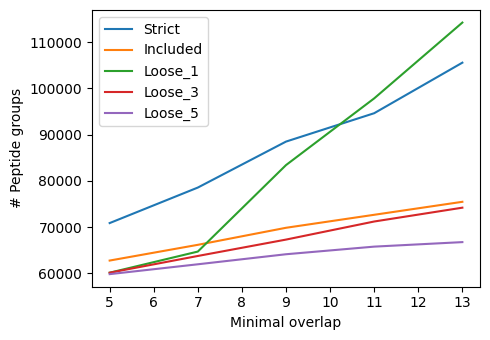

In [3]:
# load information of all runs
consensus_count = pd.DataFrame(columns={'max_step_size':'', 'min_overlap':'', 'mode':'', 'count':''})
for file in glob.glob(f'parametereffects/**/epicore.log'):
    with open(file) as f:
        lines = f.readlines()
        min_overlap = lines[1].split('min_overlap:')[1].split(',')[0]
        max_step_size = lines[1].split('max_step_size:')[1].split(',')[0]
        mode = 'loose'
        if lines[1].split('included:')[1].split(',')[0] == 'True':
            mode='included'
        elif lines[1].split('strict:')[1].split(',')[0] == 'True':
            mode='strict'
        consensus_count.loc[len(consensus_count)] = [max_step_size, min_overlap, mode, int(lines[3].split('INFO ')[1].split(' ')[0])]
fig, ax = plt.subplots(1,1, figsize=(5,3.5))

# plot the number of identified peptide groups for all runs
runs = [['strict', '5'], ['included', '5'], ['loose', '1'], ['loose', '3'], ['loose', '5']]
for run in runs:
    subset_df = consensus_count[(consensus_count['mode']==run[0])&(consensus_count['max_step_size']==run[1])].sort_values('min_overlap', key = lambda col: pd.to_numeric(col))
    run[0] = run[0][0].capitalize() + run[0][1:]
    if 'Loose' == run[0]:
        plt.plot([5,7,9,11,13], subset_df['count'], label=f'{run[0]}_{run[1]}')
    else:
        plt.plot([5,7,9,11,13], subset_df['count'], label=f'{run[0]}')

plt.subplots_adjust(top=0.99, bottom=0.01, left=0.01, right=0.99)
plt.xlabel('Minimal overlap')
plt.ylabel('# Peptide groups')
plt.legend()
plt.tight_layout()
plt.savefig('figures/reduction_modes.svg')
plt.show()

In [4]:
consensus_count

,max_step_size,min_overlap,mode,count
0,5,13,strict,105575
1,5,13,loose,66753
2,3,7,loose,63757
3,1,5,loose,60136
4,5,5,loose,59824
5,5,9,included,69854
6,5,9,loose,64129
7,3,5,loose,60136
8,5,11,loose,65777
9,5,9,strict,88502


### Complexity reduction

In [ ]:
subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'complexity_reduction/class2', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--strict'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta', '--out_dir', 'complexity_reduction/class2', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--strict'], returncode=0)

In [ ]:
subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'complexity_reduction/class1', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class1.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--strict'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta', '--out_dir', 'complexity_reduction/class1', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class1.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--strict'], returncode=0)

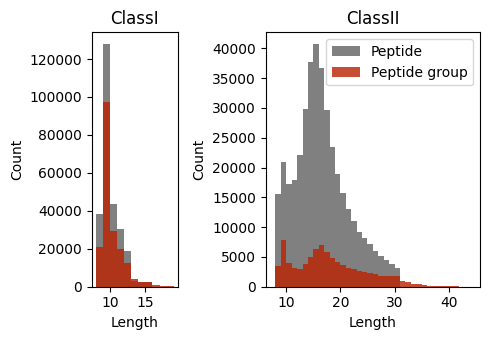

In [ ]:
# plot length distribution of peptide groups and peptides for classI
fig, axis = plt.subplots(1,2, figsize=(5,3.5), width_ratios=[1,2.5])
peptidegroups_cI_df = pd.read_csv('complexity_reduction/class1/epitopes.csv', index_col=[0])
peptidegroups_cI_df = peptidegroups_cI_df[peptidegroups_cI_df['whole_epitopes'].str.len()<50]
peptides_cI_lens = pd.read_csv('reference_class1.csv', usecols=['sequence'])['sequence'].drop_duplicates().str.len()
axis[0].set_title('ClassI')
axis[0].hist(peptides_cI_lens,bins=[i for i in range(8,20)], color='grey')
axis[0].hist(peptidegroups_cI_df['whole_epitopes'].drop_duplicates().str.len(),bins=[i for i in range(8,20)], color="#bb2402cf")
axis[0].set_xlabel('Length')
axis[0].set_ylabel('Count')

# plot length distribution of peptide groups and peptides for classII
peptidegroups_cII_df = pd.read_csv('complexity_reduction/class2/epitopes.csv', index_col=[0])
peptidegroups_cII_df = peptidegroups_cII_df[peptidegroups_cII_df['whole_epitopes'].str.len()<50]
peptides_cII_lens = pd.read_csv('reference_class2.csv', usecols=['sequence'])['sequence'].drop_duplicates().str.len()
axis[1].set_title('ClassII')
axis[1].hist(peptides_cII_lens,bins=[i for i in range(8,45)], color='grey', label='Peptide')
axis[1].hist(peptidegroups_cII_df['whole_epitopes'].drop_duplicates().str.len(),bins=[i for i in range(8,45)], color="#bb2402cf", label='Peptide group')
axis[1].set_xlabel('Length')
axis[1].set_ylabel('Count')
plt.subplots_adjust(top=0.99, bottom=0.01, left=0.01, right=0.99)
plt.legend()
plt.tight_layout()
plt.savefig('figures/complexity_reduction.svg')
plt.show()

In [ ]:
peptidegroups_cI_df = pd.read_csv('complexity_reduction/class1/epitopes.csv', index_col=[0])
peptidegroups_cII_df = pd.read_csv('complexity_reduction/class2/epitopes.csv', index_col=[0])
print(f"{len(peptidegroups_cI_df['whole_epitopes'].unique())} unique classI peptide groups were calculated.")
print(f"{len(peptidegroups_cII_df['whole_epitopes'].unique())} unique classII peptide groups were calculated.")

189970 unique classI peptide groups were calculated.
88500 unique classII peptide groups were calculated.


In [ ]:
def sort_group(subset: pd.DataFrame) -> pd.DataFrame:
    '''Sort the peptides in a dataframe according to their frequency gain. 
    
    Args:
        subset: A pandas dataframe containing one peptide group. 

    Returns: 
        A dataframe containing one sequence of the peptide group per row, where the rows are sorted with descending frequency gain. 
    '''
    # get highest frequent peptide 
    subset['length'] = subset['grouped_peptides_sample'].str.len()
    subset = subset.sort_values(['length'], ascending=False)
    fill_df = subset.iloc[[0]]
    subset = subset.iloc[1:]
    samples = set(fill_df.iloc[0]['grouped_peptides_sample'])

    # iterate over all sequences of a group
    for _ in range(len(subset)):
        subset['grouped_peptides_sample'] = subset['grouped_peptides_sample'].apply(lambda cell: [s for s in cell if s not in samples])
        subset['length'] = subset['grouped_peptides_sample'].str.len()
        subset = subset.sort_values(['length'], ascending=False)

        # get peptide adding the most frequency
        fill_df = pd.concat([fill_df, subset.iloc[[0]]])
        subset = subset.iloc[1:]
        samples = set(fill_df.iloc[0]['grouped_peptides_sample']).union(samples)
    return fill_df

def compute_freq(subset): 
    '''Compute frequencies of peptide groups with certain peptide combinations.

    Args: 
        subset: A pandas dataframe containing one peptide group. 

    Returns: 
        A dataframe containing for each row one sequence of the peptide group, each row indicates the frequency of the group with the peptide and all peptides having higher frequencies. 
    
    '''
    # calculate peptide frequency in samples of group
    subset['count'] = subset['length'].cumsum()
    subset['freq'] = subset['count']/subset['count'].max()
    
    # calculate rank of sequence in peptide group according to frequency
    subset['seq'] = [i+1 for i in range(len(subset))]
    subset['seq_freq'] = subset['seq']/subset['seq'].max()
    return subset


def freq_curve(epitopes_df, c, l):
    '''Build dataframe containing sample gain by length variant in peptide group. 
    
    Args: 
        epitopes_df: A dataframe containing the peptide groups. 
        c: Peptide group size
        l: Boolean indicating the peptide group has to be larger than c. 
    
    Returns: 
        A dataframe containing sample and peptide percentage. 
    '''

    # get all peptide groups of a certain size
    counts = epitopes_df['whole_epitopes'].value_counts()
    epitopes = counts[counts==c].index
    if l:
        epitopes = counts[counts>=c].index

    freq_df = pd.DataFrame()
    
    # iterate over all peptide groups
    for epitope in epitopes.unique():

        # get one peptide group
        epitope_df = epitopes_df[epitopes_df['whole_epitopes']==epitope].copy()
        if len(epitope_df)>1:
            epitope_df = sort_group(epitope_df)
            epitope_df = compute_freq(epitope_df)
            freq_df = pd.concat([freq_df, epitope_df])

    return freq_df

In [22]:
# load classII peptide groups
epitopes_df = pd.read_csv('complexity_reduction/class2/epitopes.csv', index_col=[0]).drop(columns={'accession'})
epitopes_df = epitopes_df.drop_duplicates(subset=['whole_epitopes','consensus_epitopes','grouped_peptides_sequence'])
epitopes_df['grouped_peptides_sequence'] = epitopes_df['grouped_peptides_sequence'].apply(lambda cell: ast.literal_eval(cell))
epitopes_df['grouped_peptides_sample'] = epitopes_df['grouped_peptides_sample'].apply(lambda cell: ast.literal_eval(cell))
epitopes_df = epitopes_df.explode(['grouped_peptides_sequence','grouped_peptides_sample'])
epitopes_df = epitopes_df.groupby(['whole_epitopes','consensus_epitopes', 'grouped_peptides_sequence']).agg({'grouped_peptides_sample':list}).reset_index()

In [ ]:
# identify how much sample frequency increases with included peptides
freq_df_3 =  freq_curve(epitopes_df, 3, False)
freq_df_6 =  freq_curve(epitopes_df, 6, False)
freq_df_9 =  freq_curve(epitopes_df, 9, False)
freq_df_10 =  freq_curve(epitopes_df, 10, True)

In [ ]:
# identify frequency of most predominant sequence
print(f"The most predominant peptide introduces a sample frequency of {freq_df_3[freq_df_3['seq']==1]['freq'].mean()} for groups of size 3.")
print(f"The most predominant peptide introduces a sample frequency of {freq_df_6[freq_df_6['seq']==1]['freq'].mean()} for groups of size 6.")
print(f"The most predominant peptide introduces a sample frequency of {freq_df_9[freq_df_9['seq']==1]['freq'].mean()} for groups of size 9.")
print(f"The most predominant peptide introduces a sample frequency of {freq_df_10[freq_df_10['seq']==1]['freq'].mean()} for groups of size >9.")


The most predominant peptide introduces a sample frequency of 0.6690287665607726 for groups of size 3.
The most predominant peptide introduces a sample frequency of 0.5025269373413765 for groups of size 6.
The most predominant peptide introduces a sample frequency of 0.41517250856278576 for groups of size 9.
The most predominant peptide introduces a sample frequency of 0.3063016050993851 for groups of size >9.


In [ ]:
print(f"The most predominant peptide introduces a sample frequency of {freq_df_3[freq_df_3['seq']==2]['freq'].mean()} for groups of size 3.")
print(f"The most predominant peptide introduces a sample frequency of {freq_df_6[freq_df_6['seq']==2]['freq'].mean()} for groups of size 6.")
print(f"The most predominant peptide introduces a sample frequency of {freq_df_9[freq_df_9['seq']==2]['freq'].mean()} for groups of size 9.")
print(f"The most predominant peptide introduces a sample frequency of {freq_df_10[freq_df_10['seq']==2]['freq'].mean()} for groups of size >9.")

The most predominant peptide introduces a sample frequency of 0.8936710757410277 for groups of size 3.
The most predominant peptide introduces a sample frequency of 0.6973772153027116 for groups of size 6.
The most predominant peptide introduces a sample frequency of 0.5822463865711089 for groups of size 9.
The most predominant peptide introduces a sample frequency of 0.4381247037139338 for groups of size >9.


In [ ]:
freq_df = pd.concat([freq_df_3,freq_df_6,freq_df_9,freq_df_10])
print(f"90% of the samples covered by a group are covered by {freq_df[freq_df['freq']>=0.90].drop_duplicates('whole_epitopes',keep='first')['seq_freq'].mean()} of the peptide group.")
print(f"99% of the samples covered by a group are covered by {freq_df[freq_df['freq']>=0.99].drop_duplicates('whole_epitopes',keep='first')['seq_freq'].mean()} of the peptide group.")

90% of the samples covered by a group are covered by 0.6688278865743501 of the peptide group.
99% of the samples covered by a group are covered by 0.7688619778378828 of the peptide group.


In [ ]:
freq_df_3['binned_freq'] = freq_df_3['seq_freq'].apply(lambda cell: round(cell*20)/20)
print(f"The standard deviation of teh sample fraction at a peptide fraction of zero is {freq_df_3[freq_df_3['seq']==1]['freq'].std(ddof=1)} for groups of size three.")
print(f"The highest value is {freq_df_3[freq_df_3['seq']==1]['freq'].max()}, while the lowest value is {freq_df_3[freq_df_3['seq']==1]['freq'].min()}.")

The standard deviation of teh sample fraction at a peptide fraction of zero is 0.22944758170800725 for groups of size three.
The highest value is 1.0, while the lowest value is 0.3333333333333333.


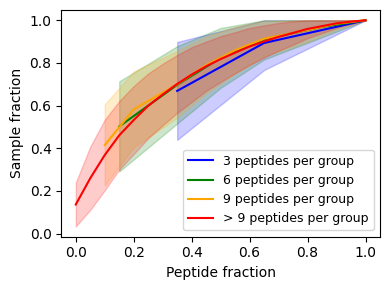

In [ ]:
# plot data
fig, axis = plt.subplots(1,1, figsize=(4,3))
freq_df_3['binned_freq'] = freq_df_3['seq_freq'].apply(lambda cell: round(cell*20)/20)
freq_df_6['binned_freq'] = freq_df_6['seq_freq'].apply(lambda cell: round(cell*20)/20)
freq_df_9['binned_freq'] = freq_df_9['seq_freq'].apply(lambda cell: round(cell*20)/20)
freq_df_10['binned_freq'] = freq_df_10['seq_freq'].apply(lambda cell: round(cell*20)/20)
sns.lineplot(data=freq_df_3, x='binned_freq', y='freq', errorbar=(lambda x: (min(1,np.mean(x)+np.std(x, ddof=1)), max(0, np.mean(x)-np.std(x, ddof=1)))), color='blue', label='3 peptides per group')
sns.lineplot(data=freq_df_6, x='binned_freq', y='freq', errorbar=(lambda x: (min(1,np.mean(x)+np.std(x, ddof=1)), max(0, np.mean(x)-np.std(x, ddof=1)))), color='green', label='6 peptides per group')
sns.lineplot(data=freq_df_9, x='binned_freq', y='freq', errorbar=(lambda x: (min(1,np.mean(x)+np.std(x, ddof=1)), max(0, np.mean(x)-np.std(x, ddof=1)))), color='orange', label='9 peptides per group')
sns.lineplot(data=freq_df_10, x='binned_freq', y='freq', errorbar=(lambda x: (min(1,np.mean(x)+np.std(x, ddof=1)), max(0, np.mean(x)-np.std(x, ddof=1)))), color='red', label='> 9 peptides per group')
plt.xlabel('Peptide fraction')
plt.ylabel('Sample fraction')
plt.legend(prop={'size':9})
plt.tight_layout()
plt.savefig('figures/freq_gain.svg')
plt.show()

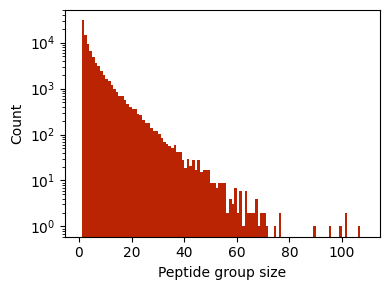

In [23]:
fig, axis = plt.subplots(1,1, figsize=(4,3))
counts = epitopes_df['whole_epitopes'].value_counts()
plt.hist(counts, bins=[i for i in range(110)], color="#bb2402ff")
plt.yscale('log')
plt.ylabel('Count')
plt.xlabel('Peptide group size')
plt.tight_layout()
plt.savefig('figures/group_size.svg')
plt.show()

In [26]:
print(f"The maximal number of peptides per group is {counts.max()}.")
print(f"The minimal number of peptides per group is {counts.min()}.")

The maximal number of peptides per group is 106.
The minimal number of peptides per group is 1.


In [ ]:
print(f"{len(counts[counts>1])} peptide groups include more than one sequence.")
print(f"{len(counts[counts==1])} peptide groups include one sequence.")

57942 peptide groups include more than one sequence.
30558 peptide groups include one sequence.


In [ ]:
print(f"The median of peptides per group is {epitopes_df['whole_epitopes'].value_counts().median()}.")

The median of peptides per group is 2.0.


### Consensus landscape

In [51]:
# reverse peptides
benign_c1_df = pd.read_csv('reference_class1_single.csv', index_col=[0])
benign_c2_df = pd.read_csv('reference_class2_single.csv', index_col=[0])
benign_c1_df['sequence'] = benign_c1_df['sequence'].apply(lambda cell: cell[::-1])
benign_c2_df['sequence'] = benign_c2_df['sequence'].apply(lambda cell: cell[::-1])
benign_c1_df.to_csv('reference_class1_reverse.csv')
benign_c2_df.to_csv('reference_class2_reverse.csv')

In [52]:
# reverse fasta
proteome_dict = {}
proteome = SeqIO.parse(open('/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta'),'fasta')
for protein in proteome:
    proteome_dict[protein.id] = str(protein.seq)[::-1]
with open('reverse_fasta.fasta','w') as prepared_fasta:
    for identifier, sequence in proteome_dict.items():
        prepared_fasta.write(f'>{identifier}\n')
        splitted_seq = [sequence[i:i+60] for i in range(0, len(sequence), 60)]
        for line in splitted_seq:
            prepared_fasta.write(f'{line}\n')

In [53]:
# run epicore for classII on regular and reverse input
subprocess.run(['epicore', '--reference_proteome','reverse_fasta.fasta' , '--out_dir', f'landscape/class2_reverse', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_reverse.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])
subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'landscape/class2', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta', '--out_dir', 'landscape/class2', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class2_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'], returncode=0)

In [55]:
# run epicore for classI on regular and reverse input
subprocess.run(['epicore', '--reference_proteome','reverse_fasta.fasta' , '--out_dir', f'landscape/class1_reverse', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class1_reverse.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])
subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'landscape/class1', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class1_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta', '--out_dir', 'landscape/class1', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'reference_class1_single.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'], returncode=0)

In [56]:
def offset(starts: str, ends: str, sequences: str, core_start: int, core_end: int) -> tuple[list[int], list[int], list[str]]:
    '''Calculate the offset of the sequences in a peptide group to the consensus sequence.

    Args: 
        starts: The start positions of the sequences.
        ends: The end positions of the sequences.
        sequences: The sequences of a peptide group.
        core_start: The start of the consensus sequence. 
        core_end: The end of the consensus sequence. 

    Returns:
        A tuple containing the N- and C-terminal offsets of the sequences to the 
        consensus sequence of the peptide group and the peptide sequences.
    '''

    Nterminal_offset = []
    Cterminal_offset = []
    sequence_list = []
    starts = ast.literal_eval(starts)
    ends = ast.literal_eval(ends)
    sequences = ast.literal_eval(sequences)
    for start, end, sequence in zip(starts, ends, sequences):
        Nterminal_offset.append(int(start)-core_start)
        Cterminal_offset.append(int(end)-core_end)
        sequence_list.append(sequence)
    return Nterminal_offset, Cterminal_offset, sequence_list

def add_offset(epitopes_csv: str) -> pd.DataFrame:
    '''Calculate the offset of all peptide groups.

    Args:
        epitopes_csv: Path to the epitopes.csv returned by epicore.

    Returns: 
        A pandas dataframe containing one peptide per row. The columns N- and C-
        terminal offset hold the information about the offset of a peptide 
        sequence to the consensus sequence of a peptide group.
    '''
    epitopes_df = pd.read_csv(epitopes_csv, index_col=[0])
    epitopes_df = epitopes_df.drop_duplicates('whole_epitopes')
    epitopes_df = epitopes_df[epitopes_df['grouped_peptides_sequence'].apply(lambda cell: len(set(ast.literal_eval(cell)))!=1)]
    epitopes_df['landscape'] = epitopes_df['landscape'].apply(lambda cell: ast.literal_eval(cell))
    epitopes_df[['Nterminal_offset','Cterminal_offset','sequences']] = epitopes_df.apply(lambda row: offset( row['grouped_peptides_start'], row['grouped_peptides_end'], row['grouped_peptides_sequence'], row['core_epitopes_start'], row['core_epitopes_end']), axis=1, result_type='expand')
    offset_df =  epitopes_df.explode(['Nterminal_offset','Cterminal_offset','sequences'])

    return offset_df

def consensus_landscape_histogram(offset_df: pd.DataFrame, axis: Axis, mhc_class: str, label: bool):
    '''Visualize offset of peptides to consensus sequence. 

    Args: 
        df: Pandas dataframe containing the offset of sequences to their consensus sequence. 
        axis: Matplotlib axis. 
        mhc_class: String indicating the mhc_class of the data. 
        label: Boolean indicating if y-label is necessary. 

    Returns: 
        A histogram visualizing the offset of sequences to their consensus sequence.     
    '''
    df = offset_df.copy()

    # ensure white space between N and C terminal offset
    #df = df[(df['Nterminal_offset']>=-20)&(df['Cterminal_offset']<=20)&((df['Nterminal_offset']!=0)|(df['Cterminal_offset']!=0))]
    axis.hist(df['Nterminal_offset'], color='#475f94', bins=[-i+0.5-2 for i in range(abs(min(df['Nterminal_offset'])))][::-1])
    axis.hist(df['Cterminal_offset'], color='#475f94', bins=[i-0.5+2 for i in range(max(df['Cterminal_offset']))])
    if label: 
        df['Nterminal_offset'] = df['Nterminal_offset'] - 2
        df['Cterminal_offset'] = df['Cterminal_offset'] + 2
        axis.set_ylabel('Peptide count')
        axis.hist(df['Nterminal_offset'], color='#475f94', bins=[-i+0.5-2 for i in range(abs(min(df['Nterminal_offset'])))][::-1])
        axis.hist(df['Cterminal_offset'], color='#475f94', bins=[i-0.5+2 for i in range(max(df['Cterminal_offset']))])
    else: 
        df['Nterminal_offset'] = - df['Nterminal_offset'] + 2
        df['Cterminal_offset'] = - df['Cterminal_offset'] - 2
        axis.hist(df['Nterminal_offset'], color='#475f94', bins=[i-0.5+2 for i in range(max(df['Nterminal_offset']))])
        axis.hist(df['Cterminal_offset'], color='#475f94', bins=[-i+0.5-2 for i in range(abs(min(df['Cterminal_offset'])))][::-1])
    if mhc_class == 'II': 
        axis.hlines(0,-22,-2,color='black', linewidth=2)
        axis.hlines(0,2,22,color='black', linewidth=2)
        axis.set_xlim(-22,22)
        axis.set_xticks([-22,-12,-2,2,12,22])
        axis.set_xticklabels([20,10,0,0,10,20])
        axis.set_yticks([50000,100000, 150000, 200000])
    else: 
        axis.hlines(0,-7,-2,color='black', linewidth=2)
        axis.hlines(0,2,7,color='black', linewidth=2)
        axis.set_xlim(-7,7)
        axis.set_xticks([-7,-2,2,7])
        axis.set_xticklabels([5,0,0,5])
        axis.set_yticks([25000,50000,75000,100000])
    axis.spines['bottom'].set_visible(False)
    axis.set_xlabel('[N-terminal]   Offset    [C-terminal]', fontsize=8)

#### ClassII

In [57]:
# identify number of peptide groups identified
allclass2_df = pd.read_csv('landscape/class2/epitopes.csv', index_col=[0])
allclass2_reverse_df = pd.read_csv('landscape/class2_reverse/epitopes.csv', index_col=[0])
print(f"There are {len(allclass2_df['grouped_peptides_sequence'].apply(lambda cell: ','.join(sorted(ast.literal_eval(cell)))).unique())} class2 peptide groups.")
print(f"There are {len(allclass2_reverse_df['grouped_peptides_sequence'].apply(lambda cell: ','.join(sorted([pep[::-1] for pep in ast.literal_eval(cell)]))).unique())} class2 peptide groups, when running epicore on the reversed data.")

There are 88504 class2 peptide groups.
There are 88212 class2 peptide groups, when running epicore on the reversed data.


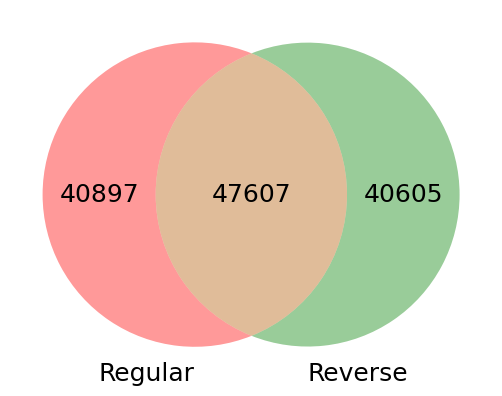

In [58]:
# create venn diagram for analyzing overlap between regular and reverse peptide groups
regular_epitopes = set(allclass2_df['grouped_peptides_sequence'].apply(lambda cell: ','.join(sorted(ast.literal_eval(cell)))))
reverse_epitopes = set(allclass2_reverse_df['grouped_peptides_sequence'].apply(lambda cell: ','.join(sorted([pep[::-1] for pep in ast.literal_eval(cell)]))))
plot = venn2([regular_epitopes, reverse_epitopes], ('Regular', 'Reverse'))
for label in plot.set_labels:
    label.set_fontsize(18)
for label in plot.subset_labels:
    label.set_fontsize(18)
plt.savefig('figures/overlap_regular_reverse_classII.svg')

In [59]:
# calculate N- and C-terminal offset
class2_df = add_offset('landscape/class2/epitopes.csv')
class2_df_reverse = add_offset('landscape/class2_reverse/epitopes.csv')

In [60]:
print(f"{88442-len(class2_df['grouped_peptides_sequence'].unique())} singleton peptide groups were removed for the regular classII run")
print(f"{88170-len(class2_df_reverse['grouped_peptides_sequence'].unique())} singleton peptide groups were removed for the reverse classII run")

30548 singleton peptide groups were removed for the regular classII run
30027 singleton peptide groups were removed for the reverse classII run


In [61]:
print(f"The N-terminal offset of classII peptides to the consensus sequence has a mean of {class2_df['Nterminal_offset'].mean()}.")
print(f"The C-terminal offset of classII peptides to the consensus sequence has a mean of {class2_df['Cterminal_offset'].mean()}.")
print(f"For the reversed input the C-terminal offset of classII peptides to the consensus sequence has a mean of {class2_df_reverse['Nterminal_offset'].mean()}.")
print(f"For the reversed input the N-terminal offset of classII peptides to the consensus sequence has a mean of {class2_df_reverse['Cterminal_offset'].mean()}.")

The N-terminal offset of classII peptides to the consensus sequence has a mean of -1.8209347398095588.
The C-terminal offset of classII peptides to the consensus sequence has a mean of 4.055684508078046.
For the reversed input the C-terminal offset of classII peptides to the consensus sequence has a mean of -1.471728080512929.
For the reversed input the N-terminal offset of classII peptides to the consensus sequence has a mean of 4.378206123482683.


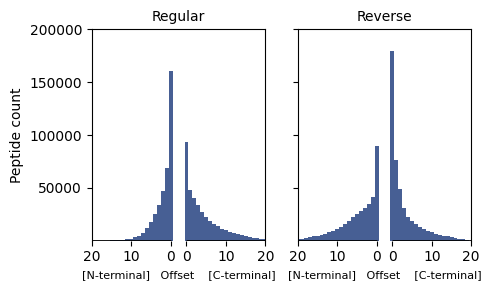

In [62]:
fig, axis = plt.subplots(1,2, figsize=(5,3), sharey=True)
consensus_landscape_histogram(class2_df, axis[0], 'II', True)
axis[0].set_title('Regular', fontsize=10)
consensus_landscape_histogram(class2_df_reverse, axis[1], 'II', False)
axis[1].set_title('Reverse', fontsize=10)
plt.tight_layout()
plt.savefig('figures/class2_landscape.svg')
plt.show()

In [63]:
print(f"{len(class2_df[(class2_df['Nterminal_offset']>0)])} N-termini of peptides start after the start position of the consensus sequence.")
print(f"{len(class2_df[(class2_df['Cterminal_offset']<0)])} C-termini of peptides end before the end position of the consensus sequence.")

4773 N-termini of peptides start after the start position of the consensus sequence.
11556 C-termini of peptides end before the end position of the consensus sequence.


In [64]:
print(f"{len(class2_df_reverse[(class2_df_reverse['Nterminal_offset']>0)])} C-termini of peptides end before the end position of the consensus sequence.")
print(f"{len(class2_df_reverse[(class2_df_reverse['Cterminal_offset']<0)])} N-termini of peptides start after the start position of the consensus sequence.")

3641 C-termini of peptides end before the end position of the consensus sequence.
13423 N-termini of peptides start after the start position of the consensus sequence.


#### ClassI

In [65]:
# identify number of peptide groups identified
allclass1_df = pd.read_csv('landscape/class1/epitopes.csv', index_col=[0])
allclass1_reverse_df = pd.read_csv('landscape/class1_reverse/epitopes.csv', index_col=[0])
print(f"There are {len(allclass1_df['grouped_peptides_sequence'].apply(lambda cell: ','.join(sorted(ast.literal_eval(cell)))).unique())} class1 peptide groups.")
print(f"There are {len(allclass1_reverse_df['grouped_peptides_sequence'].apply(lambda cell: ','.join(sorted([pep[::-1] for pep in ast.literal_eval(cell)]))).unique())} class1 peptide groups, when running epicore on the reversed data.")

There are 189912 class1 peptide groups.
There are 189900 class1 peptide groups, when running epicore on the reversed data.


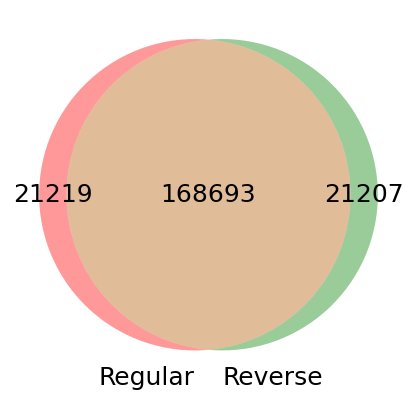

In [66]:
# create venn diagram for analyzing overlap between regular and reverse peptide groups
regular_epitopes = set(allclass1_df['grouped_peptides_sequence'].apply(lambda cell: ','.join(sorted(ast.literal_eval(cell)))))
reverse_epitopes = set(allclass1_reverse_df['grouped_peptides_sequence'].apply(lambda cell: ','.join(sorted([pep[::-1] for pep in ast.literal_eval(cell)]))))
plot = venn2([regular_epitopes, reverse_epitopes], ('Regular', 'Reverse'))
for label in plot.set_labels:
    label.set_fontsize(18)
for label in plot.subset_labels:
    label.set_fontsize(18)
plt.savefig('figures/overlap_regular_reverse_classI.svg')

In [67]:
# calculate N- and C-terminal offset
class1_df = add_offset('landscape/class1/epitopes.csv')
class1_df_reverse = add_offset('landscape/class1_reverse/epitopes.csv')

In [68]:
print(f"{189213 - len(class1_df['grouped_peptides_sequence'].unique())} singleton peptide groups were removed for the regular classI run")
print(f"{189216 - len(class1_df_reverse['grouped_peptides_sequence'].unique())} singleton peptide groups were removed for the reverse classI run")

142327 singleton peptide groups were removed for the regular classI run
142084 singleton peptide groups were removed for the reverse classI run


In [69]:
print(f"The N-terminal offset of classI peptides to the consensus sequence has a mean of {class1_df['Nterminal_offset'].mean()}.")
print(f"The C-terminal offset of classI peptides to the consensus sequence has a mean of {class1_df['Cterminal_offset'].mean()}.")
print(f"For the reversed input the C-terminal offset of classI peptides to the consensus sequence has a mean of {class1_df_reverse['Nterminal_offset'].mean()}.")
print(f"For the reversed input the N-terminal offset of classI peptides to the consensus sequence has a mean of {class1_df_reverse['Cterminal_offset'].mean()}.")

The N-terminal offset of classI peptides to the consensus sequence has a mean of -0.6566288258036691.
The C-terminal offset of classI peptides to the consensus sequence has a mean of 0.9238382033548467.
For the reversed input the C-terminal offset of classI peptides to the consensus sequence has a mean of -0.5105329998075813.
For the reversed input the N-terminal offset of classI peptides to the consensus sequence has a mean of 1.0638984029247642.


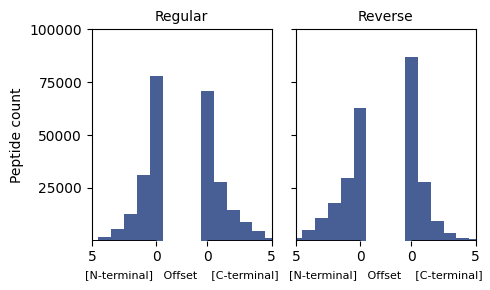

In [70]:
fig, axis = plt.subplots(1,2, figsize=(5,3), sharey=True)
consensus_landscape_histogram(class1_df, axis[0], 'I', True)
axis[0].set_title('Regular', fontsize=10)
consensus_landscape_histogram(class1_df_reverse, axis[1], 'I', False)
axis[1].set_title('Reverse', fontsize=10)
plt.tight_layout()
plt.savefig('figures/class1_landscape.svg')
plt.show()

In [71]:
print(f"{len(class1_df[(class1_df['Nterminal_offset']>0)])} N-termini of peptides start after the start position of the consensus sequence.")
print(f"{len(class1_df[(class1_df['Cterminal_offset']<0)])} C-termini of peptides end before the end position of the consensus sequence.")

0 N-termini of peptides start after the start position of the consensus sequence.
0 C-termini of peptides end before the end position of the consensus sequence.


In [72]:
print(f"{len(class1_df_reverse[(class1_df_reverse['Nterminal_offset']>0)])} C-termini of peptides end before the end position of the consensus sequence.")
print(f"{len(class1_df_reverse[(class1_df_reverse['Cterminal_offset']<0)])} N-termini of peptides start after the start position of the consensus sequence.")

0 C-termini of peptides end before the end position of the consensus sequence.
0 N-termini of peptides start after the start position of the consensus sequence.


### Allotype composition

In [ ]:
# load data
peptides_df = pd.read_parquet('el_db.parquet')
peptides_df = peptides_df[peptides_df['el']==1]
peptides_df = peptides_df[peptides_df['peptide'].str.len().between(8,25)]
peptides_df = peptides_df.rename(columns={'peptide':'sequence'})

In [ ]:
# annotate peptides
peptide_lengths = list(set(get_peptide_lengths(peptides_df)))
proteome_dict = proteome_to_dict('UP000005640_9606.fasta')
fasta_dict = create_fasta_dict(proteome_dict, peptide_lengths)
peptides_df = annotate_peptides(fasta_dict, peptides_df)
peptides_df = add_positions(proteome_dict, peptides_df, 'accessions','sequence')
print(f"{len(peptides_df[peptides_df['accessions']=='unmapped']['sequence'].unique())}/{len(peptides_df['sequence'].unique())} peptides are removed due to missing annotations.")
peptides_df['alleles'] = peptides_df['alleles'].apply(lambda cell: [allele for allele in cell.split(',') if allele[0:3]=='HLA'] if 'HLA-D' not in cell else [cell])
peptides_df = peptides_df.explode('alleles')
peptides_df = peptides_df[~(peptides_df['alleles'].isna())]
peptides_df = peptides_df.rename(columns={'alleles':'sample','source':'condition'})
peptides_df = peptides_df[peptides_df['accessions']!='unmapped']
peptides_df.to_csv('combined_peptides.csv')
class2_df = peptides_df[peptides_df['sample'].apply(lambda allele: any([typing in allele for typing in ['HLA-DR','HLA-DP','HLA-DQ']]))]
class1_df = peptides_df[~peptides_df['sample'].apply(lambda allele: any([typing in allele for typing in ['HLA-DR','HLA-DP','HLA-DQ']]))]
class2_df.to_csv('class2_peptides.csv')
class1_df.to_csv('class1_peptides.csv')

67026/833660 peptides are removed due to missing annotations.


In [ ]:
print(f"{len(class1_df['sequence'].unique())} unique classI peptides are contained in the dataset.")
print(f"{len(class2_df['sequence'].unique())} unique classII peptides are contained in the dataset.")
print(f"{len(class1_df['sample'].unique())} classI allotypes are represented in the dataset.")
print(f"{len(class2_df['sample'].unique())} classII allotypes are represented in the dataset.")

390660 unique classI peptides are contained in the dataset.
346365 unique classII peptides are contained in the dataset.
170 classI allotypes are represented in the dataset.
77 classII allotypes are represented in the dataset.


In [ ]:
subprocess.run(['epicore', '--reference_proteome', 'UP000005640_9606.fasta', '--out_dir', 'allotype_composition/class2_9', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])
subprocess.run(['epicore', '--reference_proteome', 'UP000005640_9606.fasta', '--out_dir', 'allotype_composition/class2_11', 'generate-epicore-csv', '--min_epi_length', '11', '--min_overlap', '11', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])
subprocess.run(['epicore', '--reference_proteome', 'UP000005640_9606.fasta', '--out_dir', 'allotype_composition/class2_13', 'generate-epicore-csv', '--min_epi_length', '13', '--min_overlap', '13', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])

CompletedProcess(args=['epicore', '--reference_proteome', 'UP000005640_9606.fasta', '--out_dir', 'allotype_composition/class2_13', 'generate-epicore-csv', '--min_epi_length', '13', '--min_overlap', '13', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'], returncode=0)

In [ ]:
subprocess.run(['epicore', '--reference_proteome', 'UP000005640_9606.fasta', '--out_dir', 'allotype_composition/class1', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class1_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])

CompletedProcess(args=['epicore', '--reference_proteome', 'UP000005640_9606.fasta', '--out_dir', 'allotype_composition/class1', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class1_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'], returncode=0)

In [ ]:
def shared(allotypes: list[str], sequences: list[str], supertype_dict: dict, supertypes: bool) -> dict[str, int]:
    '''Compute allotype/supertype count in peptide group. 

    Args: 
        allotypes: List of allotypes of the samples. 
        sequences: List of peptide sequence of the samples. 
        supertype_dict: Dictionary containing mapping of allotype to supertypes. 
        supertypes: Boolean indicating if allotype or supertype is analyzed. 

    Returns: 
        Returns dictionary containing the count of allotypes/supertypes in a peptide group. 
    
    '''
    allotype_count = {}
    seen = []

    # iterate over all sequences with their respective allotype
    for allotype, sequence in zip(allotypes, sequences):

        
        if supertypes:
            if ('Q' in allotype) or (',' not in allotype): 
                allotype = [supertype_dict[allotype] if allotype in supertype_dict.keys() else allotype][0]
            else: 
                allotype = [supertype_dict[allotype.split(',')[1]] if allotype.split(',')[1] in supertype_dict.keys() else allotype.split(',')[1]][0]

            
        if f'{allotype}_{sequence}' in seen:
            continue
        else:
            seen.append(f'{allotype}_{sequence}')

        # add allotype/supertype occurrence
        if allotype in allotype_count.keys():
            allotype_count[allotype] += 1
        else:
            allotype_count[allotype] = 1
    return allotype_count


def predominant_count(count_dict: dict[str, int]) -> int:
    '''Identify count of predominant supertype/allotype.

    Args: 
        count_dict: Dictionary containing allotype/supertype count. 

    Returns: 
        Count of predominant supertype/allotype. 
    '''
    sorted_dict = sorted(count_dict.items(), key=operator.itemgetter(1), reverse=True)
    for (key, _) in sorted_dict:
        return count_dict[key]
    return 0


def predominant_allotype(epitopes_csv: str, supertype_dict: dict[str, str]) -> pd.DataFrame:
    '''Compute number of sequences sharing allotype/supertype.
    
    Args: 
        epitopes_csv: Epicore output. 
        supertype_dict: Dictionary containing mapping of allotypes to supertypes. 
        
    Returns:
        Pandas dataframe containing number of sequences sharing allotype/supertype. 
    '''
    # load data
    epitopes_df = pd.read_csv(epitopes_csv, index_col=[0])
    epitopes_df = epitopes_df.drop_duplicates(['whole_epitopes','consensus_epitopes','grouped_peptides_sequence'])
    epitopes_df['grouped_peptides_sequence'] = epitopes_df['grouped_peptides_sequence'].apply(lambda sequences: ast.literal_eval(sequences))
    epitopes_df['grouped_peptides_sample'] = epitopes_df['grouped_peptides_sample'].apply(lambda alleles: ast.literal_eval(alleles))

    # count sequences sharing specific allotype
    epitopes_df['allotype_count'] = epitopes_df.apply(lambda row: shared(row['grouped_peptides_sample'], row['grouped_peptides_sequence'], supertype_dict, False), axis=1)
    epitopes_df['supertype_count'] = epitopes_df.apply(lambda row: shared(row['grouped_peptides_sample'], row['grouped_peptides_sequence'], supertype_dict, True), axis=1)

    # get predominant count
    epitopes_df['max_allotype'] = epitopes_df['allotype_count'].apply(lambda count: max(count.values()))
    epitopes_df['max_supertype'] = epitopes_df['supertype_count'].apply(lambda count: max(count.values()))

    return epitopes_df


def plot_group_composition(epitopes_df: pd.DataFrame, out_path: str, category: str, min_overlap: str):
    ''' Visualize the allotype/supertype composition of a peptide group. 

    Args: 
        epitopes_df: A pandas dataframe containing the allotype/supertype composition of a peptide group. 
        out_path: Path where plot should be stored. 
        category: str indicating if allotype or supertypes are considered.
        min_overlap: str indicating the min_overlap specified in epicore. 
    '''

    # create colormap
    cmap = plt.get_cmap('Reds_r',12)
    colors = [cmap(i) for i in range(cmap.N)]
    df = pd.DataFrame({'peps sharing': [], '0':[], '1':[], '2':[],'3':[],'4':[],'5':[],'6':[],'7':[],'8':[],'9':[],'10':[],'>10':[]})
    mp = plt.cm.ScalarMappable(cmap=cmap)

    # iterate over number of peptides not sharing most frequent allotype
    for peps_missing in range(10): 
        # get peptide groups with n_peps missing allotype 
        subset_df = epitopes_df[epitopes_df['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))==epitopes_df[f'max_{category}']+peps_missing]
        df.loc[len(df)] = [peps_missing] + [len(subset_df[(subset_df['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))==g_size)]) if g_size != 13 else len(subset_df[(subset_df['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))>=g_size)]) for g_size in range(2,14)]

    # build stacked bar plot
    ax = df.plot(x='peps sharing', kind='bar', stacked=True, color=colors, width=0.9, figsize=(5,4))
    ax.get_legend().remove()

    # create colorbar
    cbar = plt.colorbar(mp, ax=ax)
    cbar.set_ticks([0.03,0.29,0.55,0.79,0.97])
    cbar.set_ticklabels([2,5,8,11,'>14'])
    cbar.set_label('# Peptides in group')

    # add labels
    plt.xticks(rotation=0)
    plt.xlabel(f'# Peptides not presented by predominant {category}')
    plt.ylabel('# Peptide groups')
    plt.title(f'HLA {category}, min_overlap: {min_overlap}')
    plt.tight_layout()
    plt.savefig(out_path)

In [ ]:
# define supertypes according to Greenman et al. (doi: 10.1007/s00251-011-0513-0)
supertype_dict = {'HLA-DRB1*01:01':'Main DR','HLA-DRB1*07:01':'Main DR','HLA-DRB1*09:01':'Main DR','HLA-DRB1*11:01':'Main DR','HLA-DRB1*12:01':'Main DR','HLA-DRB1*15:01':'Main DR','HLA-DRB5*01:01':'Main DR','HLA-DPB1*14:01':'Main DR','HLA-DRB1*04:01':'DR4','HLA-DRB1*04:05':'DR4','HLA-DRB1*08:02':'DR4','HLA-DRB1*03:01':'DRB3','HLA-DRB1*13:02':'DRB3','HLA-DRB3*01:01':'DRB3','HLA-DRB3*02:02':'DRB3','HLA-DRB4*01:01':'DRB3','HLA-DPB1*01:01':'Main DP','HLA-DPB1*04:02':'Main DP','HLA-DPB1*05:01':'Main DP','HLA-DPB1*02:01':'DP2','HLA-DPB1*04:01':'DP2','HLA-DQA1*05:01,HLA-DQB1*02:01':'Main DQ','HLA-DQA1*03:01,HLA-DQB1*03:02':'Main DQ','HLA-DQA1*04:01,HLA-DQB1*04:02':'Main DQ','HLA-DQA1*01:01,HLA-DQB1*05:01':'Main DQ','HLA-DQA1*05:01,HLA-DQB1*03:01':'DQ7','HLA-DQA1*01:02,HLA-DQB1*06:02':'DQ7'}

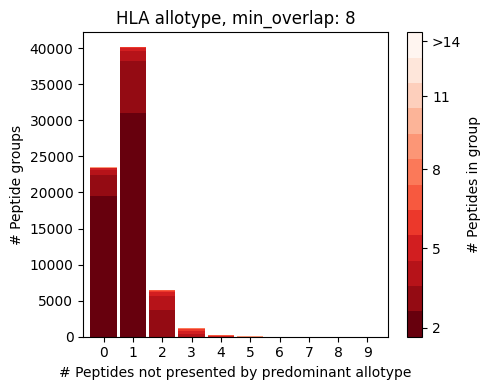

In [ ]:
# identify number of shared HLA allotypes for classI peptide groups
epitopes_df_class1 = predominant_allotype('allotype_composition/class1/epitopes.csv', supertype_dict)
plot_group_composition(epitopes_df_class1, 'figures/allotype_composition1.svg', 'allotype', 8)

In [ ]:
# identify number of sequences missing most frequent allotype
r_singleton = epitopes_df_class1[epitopes_df_class1['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))>1)]
r_singleton['missing'] = r_singleton['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))) - r_singleton['max_allotype']
r_singleton['missing'].value_counts()

missing
1     40199
0     23472
2      6484
3      1184
4       275
5        64
6        22
7         8
8         5
10        1
Name: count, dtype: int64

In [ ]:
# get group sizes
r_singleton['grouped_peptides_sequence'].apply(lambda seqs: len(set(seqs))).value_counts()

grouped_peptides_sequence
2     50556
3     13892
4      4385
5      1574
6       667
7       309
8       138
9        74
10       49
11       25
12       15
13       11
14        7
15        5
16        5
17        1
18        1
Name: count, dtype: int64

In [ ]:
# get peptides of largest group
set(r_singleton[r_singleton['grouped_peptides_sequence'].apply(lambda seqs: len(set(seqs)))==18].iloc[0]['grouped_peptides_sequence'])

{'ALDFFGNGPPVNY',
 'ALDFFGNGPPVNYK',
 'DFFGNGPPVNY',
 'DFFGNGPPVNYK',
 'DFFGNGPPVNYKT',
 'DFFGNGPPVNYKTG',
 'FFGNGPPVNY',
 'FFGNGPPVNYK',
 'FFGNGPPVNYKT',
 'FFGNGPPVNYKTG',
 'FGNGPPVNYK',
 'FGNGPPVNYKT',
 'FGNGPPVNYKTG',
 'FGNGPPVNYKTGN',
 'GNGPPVNYK',
 'GNGPPVNYKTG',
 'LDFFGNGPPVNYK',
 'LDFFGNGPPVNYKT'}

In [ ]:
# get allotype composition of largest group
r_singleton[r_singleton['grouped_peptides_sequence'].apply(lambda seqs: len(set(seqs)))==18].iloc[0]['allotype_count']

{'HLA-C*07:01': 8,
 'HLA-C*06:02': 5,
 'HLA-C*05:01': 7,
 'HLA-B*27:09': 3,
 'HLA-B*08:01': 4,
 'HLA-A*24:02': 8,
 'HLA-A*11:01': 3,
 'HLA-A*02:01': 5,
 'HLA-A*01:01': 1,
 'HLA-C*03:03': 2,
 'HLA-B*18:01': 2,
 'HLA-B*15:01': 2,
 'HLA-A*03:01': 2,
 'HLA-C*07:02': 10,
 'HLA-B*07:02': 3,
 'HLA-C*03:04': 7,
 'HLA-C*04:01': 8,
 'HLA-C*17:01': 2,
 'HLA-A*29:02': 1,
 'HLA-C*16:01': 1,
 'HLA-C*12:03': 1,
 'HLA-C*02:02': 3,
 'HLA-B*51:01': 1}

Only one of the peptides is weak binder of HLA-C*07:02 with netMHCpan-4.1.

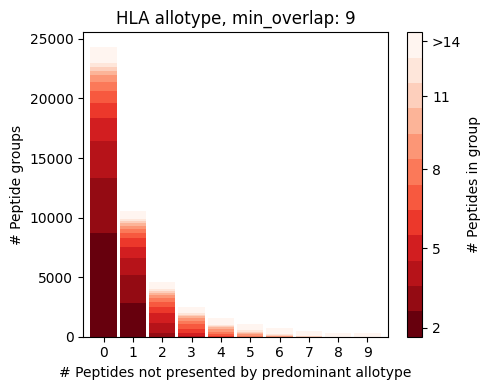

In [ ]:
# allotype, min_overlap 9
epitopes_df_class2_9 = predominant_allotype('allotype_composition/class2_9/epitopes.csv', supertype_dict)
plot_group_composition(epitopes_df_class2_9, 'figures/allotype_composition.svg', 'allotype', 9)

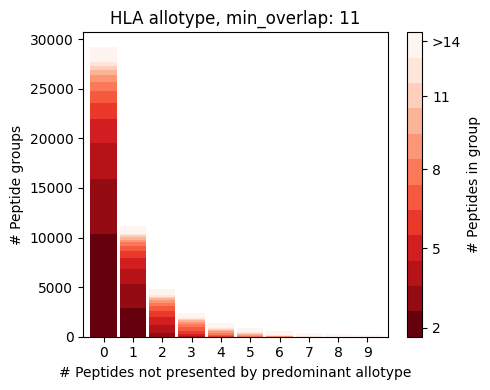

In [ ]:
# allotype, min_overlap 11
epitopes_df_class2_11 = predominant_allotype('allotype_composition/class2_11/epitopes.csv', supertype_dict)
plot_group_composition(epitopes_df_class2_11, 'figures/allotype_composition_11.svg', 'allotype', 11)

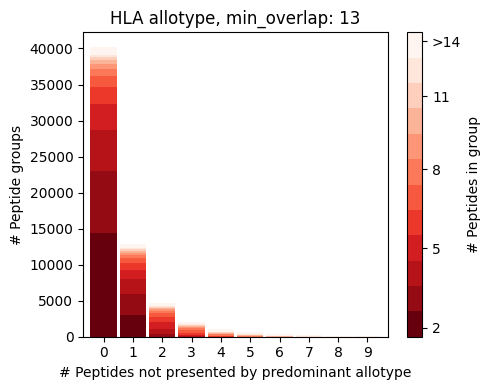

In [ ]:
# allotype, min_overlap 13
epitopes_df_class2_13 = predominant_allotype('allotype_composition/class2_13/epitopes.csv', supertype_dict)
plot_group_composition(epitopes_df_class2_13, 'figures/allotype_composition_13.svg', 'allotype', 13)

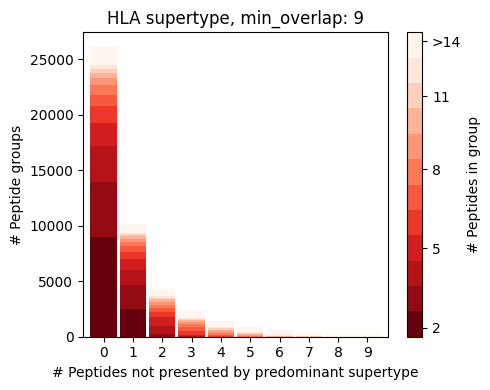

In [ ]:
# supertype, min_overlap 9
epitopes_df_class2_supertype = predominant_allotype('allotype_composition/class2_9/epitopes.csv', supertype_dict)
plot_group_composition(epitopes_df_class2_supertype, 'figures/supertype_composition_9.svg', 'supertype', 9)

In [ ]:
# identify number of peptide groups
print(f"There are {len(epitopes_df_class2_9)} peptide groups for min_overlap 9.")
print(f"There are {len(epitopes_df_class2_11)} peptide groups for min_overlap 11.")
print(f"There are {len(epitopes_df_class2_13)} peptide groups for min_overlap 13.")

There are 73573 peptide groups for min_overlap 9.
There are 81228 peptide groups for min_overlap 11.
There are 96879 peptide groups for min_overlap 13.


In [ ]:
# identify number of peptide groups containing more than one sequence
print(f"There are {len(epitopes_df_class2_9[epitopes_df_class2_9['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))>1)])} peptide groups containing more than one sequence for min_overlap 9.")
print(f"There are {len(epitopes_df_class2_11[epitopes_df_class2_11['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))>1)])} peptide groups containing more than one sequence for min_overlap 11.")
print(f"There are {len(epitopes_df_class2_13[epitopes_df_class2_13['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))>1)])} peptide groups containing more than one sequence for min_overlap 13.")

There are 47460 peptide groups containing more than one sequence for min_overlap 9.
There are 51631 peptide groups containing more than one sequence for min_overlap 11.
There are 62257 peptide groups containing more than one sequence for min_overlap 13.


In [ ]:
# identify number of peptide groups, where all sequence share at least one allotype
print(f"There are {len(epitopes_df_class2_9[(epitopes_df_class2_9['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))==epitopes_df_class2_9['max_allotype'])&(epitopes_df_class2_9['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))>1)])} peptide groups where all sequences share at least one allotype for min_overlap 9.")
print(f"There are {len(epitopes_df_class2_11[(epitopes_df_class2_11['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))==epitopes_df_class2_11['max_allotype'])&(epitopes_df_class2_11['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))>1)])} peptide groups where all sequences share at least one allotype for min_overlap 11.")
print(f"There are {len(epitopes_df_class2_13[(epitopes_df_class2_13['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))==epitopes_df_class2_13['max_allotype'])&(epitopes_df_class2_13['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))>1)])} peptide groups where all sequences share at least one allotype for min_overlap 13.")
print(f"There are {len(epitopes_df_class2_supertype[(epitopes_df_class2_supertype['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))==epitopes_df_class2_supertype['max_supertype'])&(epitopes_df_class2_supertype['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))>1)])} peptide groups where all sequences share at least one allotype for min_overlap 9.")

There are 24332 peptide groups where all sequences share at least one allotype for min_overlap 9.
There are 29223 peptide groups where all sequences share at least one allotype for min_overlap 11.
There are 40229 peptide groups where all sequences share at least one allotype for min_overlap 13.
There are 26107 peptide groups where all sequences share at least one allotype for min_overlap 9.


In [ ]:
# identify maximal group size for groups, where all peptides share at least one allotype
one_allotype = epitopes_df_class2_9[(epitopes_df_class2_9['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))==epitopes_df_class2_9['max_allotype'])&(epitopes_df_class2_9['grouped_peptides_sequence'].apply(lambda cell: len(set(cell)))>1)]
one_allotype['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))).max()

np.int64(62)

In [ ]:
# analyze how many groups exist for different number of sequences sharing the same allotype
r_singleton = epitopes_df_class2_9[epitopes_df_class2_9['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))>1)]
r_singleton['missing'] = r_singleton['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))) - r_singleton['max_allotype']
r_singleton['missing'].value_counts()

missing
0     24332
1     10582
2      4592
3      2535
4      1568
5      1030
6       707
7       503
8       350
9       302
10      230
11      169
12      120
13       95
14       73
16       48
15       47
17       40
18       27
20       25
19       22
21       17
22       10
23        7
24        7
25        6
26        6
28        3
29        2
30        2
37        1
31        1
27        1
Name: count, dtype: int64

In [ ]:
# analyze how many groups exist for different number of sequences sharing the same allotype
r_singleton = epitopes_df_class2_13[epitopes_df_class2_13['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))>1)]
r_singleton['missing'] = r_singleton['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))) - r_singleton['max_allotype']
r_singleton['missing'].value_counts()

missing
0     40229
1     12848
2      4640
3      2091
4      1041
5       587
6       314
7       203
8       129
9        59
10       41
11       25
13       16
12       15
15        6
16        4
14        3
18        2
17        2
20        1
19        1
Name: count, dtype: int64

In [ ]:
# analyze how many groups exist for different number of sequences sharing the same allotype
r_singleton = epitopes_df_class2_supertype[epitopes_df_class2_supertype['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))>1)]
r_singleton['missing'] = r_singleton['grouped_peptides_sequence'].apply(lambda cell: len(set(cell))) - r_singleton['max_supertype']
r_singleton['missing'].value_counts()

missing
0     26107
1     10137
2      4317
3      2322
4      1394
5       919
6       597
7       451
8       288
9       232
10      175
11      131
12       90
13       79
14       54
15       36
17       31
16       24
18       17
20       15
19       12
21        8
22        8
23        5
25        4
26        2
37        1
24        1
30        1
29        1
28        1
Name: count, dtype: int64

### Analyze runtime
Analyze the runtime of epicore for different number of input peptides. 

In [2]:
# prepare input data of size 100, 1000, 10000, 100000 and 1000000
input_df = pd.read_csv('reference_class2.csv', index_col=[0])
input_df.iloc[0:100].to_csv('input_100.csv')
input_df.iloc[0:1000].to_csv('input_1000.csv')
input_df.iloc[0:10000].to_csv('input_10000.csv')
input_df.iloc[0:100000].to_csv('input_100000.csv')
input_df.iloc[0:1000000].to_csv('input_1000000.csv')

In [3]:
strict = []
included = []
loose = []
for count in [100,1000,10000,100000,1000000]:
    
    # strict 
    start_time = time()
    subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'runtime/strict_{count}', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', f'input_{count}.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--strict'])
    strict.append(time()-start_time)

    # included
    start_time = time()
    subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'runtime/included_{count}', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', f'input_{count}.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--included'])
    included.append(time()-start_time)

    # loose
    start_time = time()
    subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'runtime/loose_{count}', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', f'input_{count}.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end'])
    loose.append(time()-start_time)

In [4]:
strict

[4.366357088088989,
 4.989834308624268,
 9.329929828643799,
 43.04735612869263,
 328.77780961990356]

In [5]:
included

[4.171512126922607,
 4.862479209899902,
 9.802297830581665,
 45.30850338935852,
 455.1881203651428]

In [6]:
loose

[4.6398234367370605,
 6.169287919998169,
 14.082619667053223,
 61.799723625183105,
 489.75525069236755]

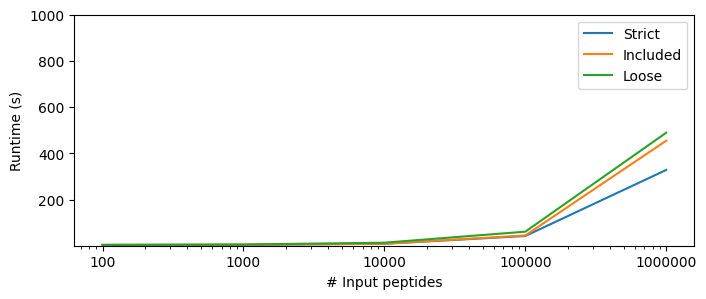

In [19]:
# plot runtime of all three modes 
fig, axis = plt.subplots(1,1, figsize=(8,3))
plt.plot([100,1000,10000,100000,1000000], strict, label='Strict')
plt.plot([100,1000,10000,100000,1000000], included, label='Included')
plt.plot([100,1000,10000,100000,1000000], loose, label='Loose')
#lt.plot([100,1000000],[100,1000000])
plt.xlabel('# Input peptides')
plt.ylabel('Runtime (s)')
plt.xscale('log')
plt.xticks([100,1000,10000,100000,1000000],[100,1000,10000,100000,1000000])
plt.legend()
plt.ylim(1,1000)
plt.show()

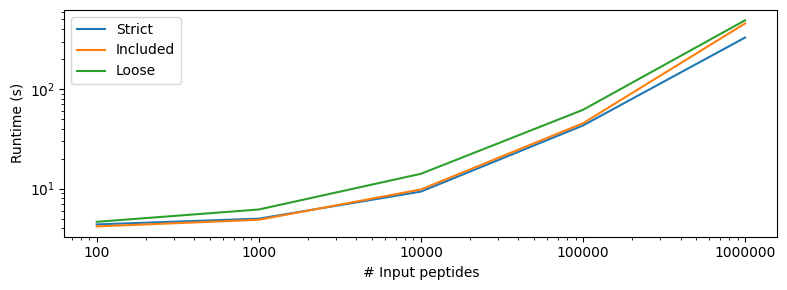

In [21]:
# plot runtime of all three modes 
import matplotlib.pyplot as plt
fig, axis = plt.subplots(1,1, figsize=(8,3))
size = [100,1000,10000,100000,1000000]
plt.plot(size, strict, label='Strict')
plt.plot(size, included, label='Included')
plt.plot(size, loose, label='Loose')
#plt.plot(size, [i/100 for i in size], label='O(n)', color='grey', linestyle='--')
plt.xlabel('# Input peptides')
plt.ylabel('Runtime (s)')
plt.yscale('log')
plt.xscale('log')
plt.xticks([100,1000,10000,100000,1000000],[100,1000,10000,100000,1000000])
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# runtime per sample (strict mode)
for i in range(0,5):
    print(strict[i]/pow(10,i+2))

0.043663570880889895
0.004989834308624268
0.0009329929828643798
0.0004304735612869263
0.00032877780961990355


In [45]:
# runtime per sample (included mode)
for i in range(0,5):
    print(included[i]/pow(10,i+2))

0.04171512126922607
0.004862479209899902
0.0009802297830581665
0.0004530850338935852
0.0004551881203651428


In [46]:
# runtime per sample (loose mode)
for i in range(0,5):
    print(loose[i]/pow(10,i+2))

0.0463982343673706
0.006169287919998169
0.0014082619667053222
0.000617997236251831
0.0004897552506923675


In [15]:
# identify the slop (strict mode)
slope_strict = []
for i in range(1,5):
    slope_strict.append((strict[i]-strict[i-1])/(pow(10,i+2)-pow(10,i+1)))
print(slope_strict)

[0.0006927524672614203, 0.0004822328355577257, 0.0003746380700005425, 0.00031747828165690103]


In [16]:
# identify the slop (included mode)
slope_included = []
for i in range(1,5):
    slope_included.append((included[i]-included[i-1])/(pow(10,i+2)-pow(10,i+1)))
print(slope_included)

[0.0007677412033081054, 0.0005488687356313069, 0.0003945133950975206, 0.00045542179663976036]


In [17]:
# identify identify the slop (loose mode)
slope_loose  = []
for i in range(1,5):
    slope_loose.append((loose[i]-loose[i-1])/(pow(10,i+2)-pow(10,i+1)))
print(slope_loose)

[0.0016994049814012316, 0.000879259083006117, 0.0005301900439792209, 0.0004755061411857605]


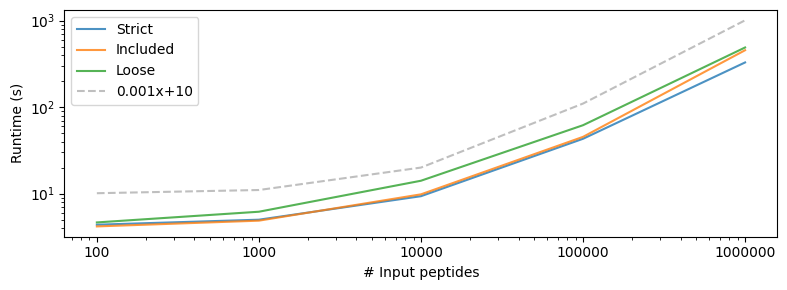

In [18]:
# plot runtime of all three modes 
import matplotlib.pyplot as plt
fig, axis = plt.subplots(1,1, figsize=(8,3))
size = [100,1000,10000,100000,1000000]
plt.plot(size, strict, label='Strict', alpha=0.8)
plt.plot(size, included, label='Included', alpha=0.8)
plt.plot(size, loose, label='Loose', alpha=0.8)
plt.plot(size, [0.001*i+10 for i in size], label='0.001x+10', color='grey', linestyle='--', alpha=0.5)
plt.xlabel('# Input peptides')
plt.ylabel('Runtime (s)')
plt.yscale('log')
plt.xscale('log')
plt.xticks([100,1000,10000,100000,1000000],[100,1000,10000,100000,1000000])
plt.legend()
plt.tight_layout()
plt.savefig('figures/runtime.svg')